In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
# b

In [34]:
# Columns: PI , PT , LLA , SS , PR , GS , Class (0=No, 1=Ab)

df = pd.read_csv("vertebral_column_data/column_2C.dat", sep=r"\s+", header=None)

df.columns = ["PI", "PT", "LLA", "SS", "PR", "GS", "Class"]

df["Class"] = df["Class"].replace({"NO": 0, "AB": 1})

print(df.head(20))

       PI     PT    LLA     SS      PR     GS  Class
0   63.03  22.55  39.61  40.48   98.67  -0.25      1
1   39.06  10.06  25.02  29.00  114.41   4.56      1
2   68.83  22.22  50.09  46.61  105.99  -3.53      1
3   69.30  24.65  44.31  44.64  101.87  11.21      1
4   49.71   9.65  28.32  40.06  108.17   7.92      1
5   40.25  13.92  25.12  26.33  130.33   2.23      1
6   53.43  15.86  37.17  37.57  120.57   5.99      1
7   45.37  10.76  29.04  34.61  117.27 -10.68      1
8   43.79  13.53  42.69  30.26  125.00  13.29      1
9   36.69   5.01  41.95  31.68   84.24   0.66      1
10  49.71  13.04  31.33  36.67  108.65  -7.83      1
11  31.23  17.72  15.50  13.52  120.06   0.50      1
12  48.92  19.96  40.26  28.95  119.32   8.03      1
13  53.57  20.46  33.10  33.11  110.97   7.04      1
14  57.30  24.19  47.00  33.11  116.81   5.77      1
15  44.32  12.54  36.10  31.78  124.12   5.42      1
16  63.83  20.36  54.55  43.47  112.31  -0.62      1
17  31.28   3.14  32.56  28.13  129.01   3.62 

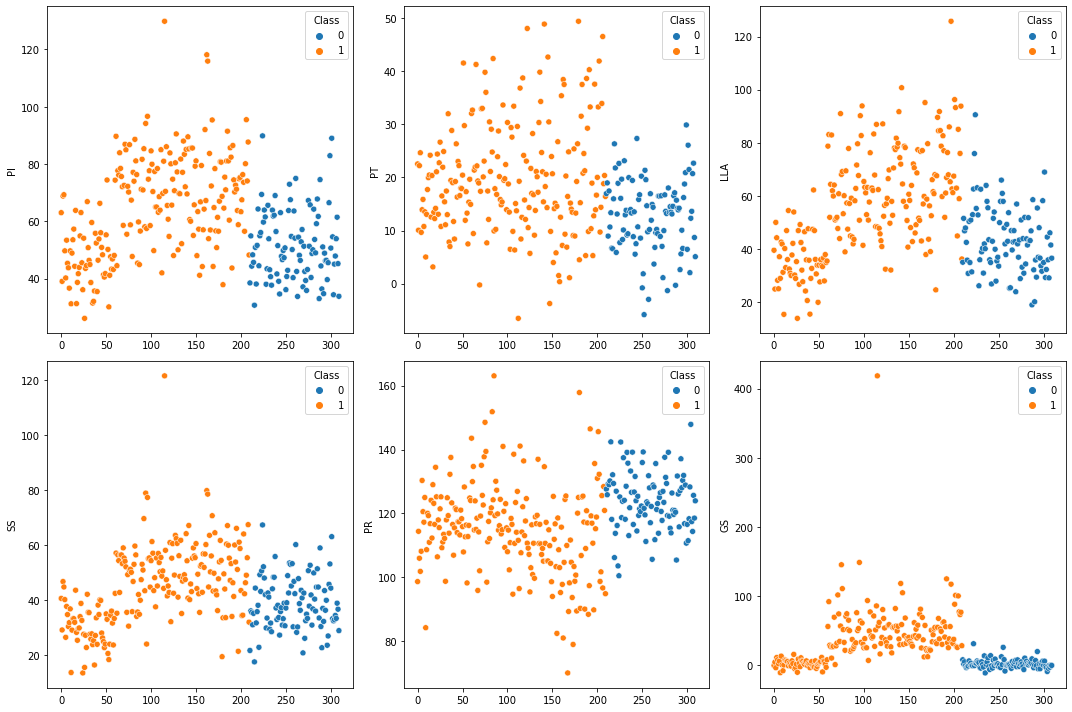

In [35]:
# It is a Python library specifically designed for creating statistical charts and graphs

fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.scatterplot(data=df, x=df.index, y="PI", hue="Class", ax=axes[0,0])
sns.scatterplot(data=df, x=df.index, y="PT", hue="Class", ax=axes[0,1])
sns.scatterplot(data=df, x=df.index, y="LLA", hue="Class", ax=axes[0,2])

sns.scatterplot(data=df, x=df.index, y="SS", hue="Class", ax=axes[1,0])
sns.scatterplot(data=df, x=df.index, y="PR", hue="Class", ax=axes[1,1])
sns.scatterplot(data=df, x=df.index, y="GS", hue="Class", ax=axes[1,2])

plt.tight_layout()
plt.show()

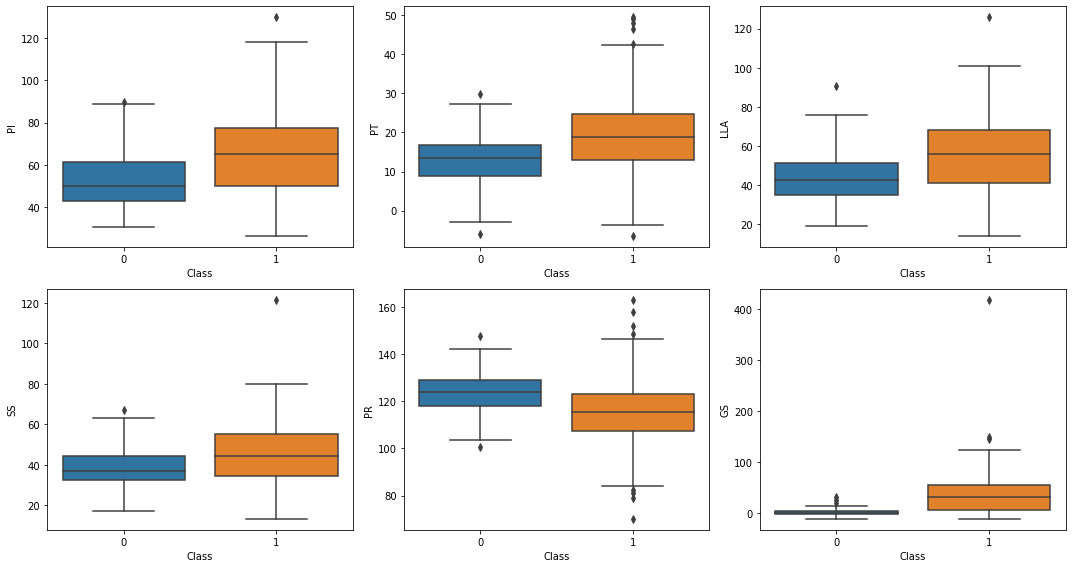

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(data=df, x="Class", y="PI",  ax=axes[0, 0])
sns.boxplot(data=df, x="Class", y="PT",  ax=axes[0, 1])
sns.boxplot(data=df, x="Class", y="LLA", ax=axes[0, 2])

sns.boxplot(data=df, x="Class", y="SS",  ax=axes[1, 0])
sns.boxplot(data=df, x="Class", y="PR",  ax=axes[1, 1])
sns.boxplot(data=df, x="Class", y="GS",  ax=axes[1, 2])

plt.tight_layout()
plt.show()

In [37]:
class0 = df[df["Class"] == 0]
class1 = df[df["Class"] == 1]
#integer location，rows by numerical position
train_data = pd.concat([class0.iloc[:70],class1.iloc[:140]]) 
test_data = pd.concat([class0.iloc[70:],class1.iloc[140:]])

In [38]:
train1 = train_data.drop("Class", axis=1)
train2 = train_data["Class"]

test1 = test_data.drop("Class", axis=1)
test2 = test_data["Class"]

print(train1.shape)
print(train1.shape)
print(test2.shape)
print(test2.shape)

(210, 6)
(210, 6)
(100,)
(100,)


In [39]:
# c

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score

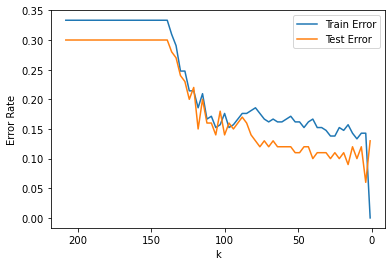

In [41]:
train_errors = []
test_errors = []

for k in range(208, 0, -3):

    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(train1, train2)
    Y_trainout = knn.predict(train1)
    Y_testout = knn.predict(test1)
    train_error = 1 - accuracy_score(train2, Y_trainout)
    test_error = 1 - accuracy_score(test2, Y_testout)
    train_errors.append(train_error)
    test_errors.append(test_error)


plt.plot(range(208, 0, -3), train_errors, label="Train Error")
plt.plot(range(208, 0, -3), test_errors, label="Test Error")
plt.xlabel("k")
plt.ylabel("Error Rate")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

In [42]:
k_values = list(range(208, 0, -3))

min_error = min(test_errors)

index = test_errors.index(min_error)

k_star = k_values[index]

print("Best k =", k_star)
print("Min Test Error =", min_error)

Best k = 4
Min Test Error = 0.06000000000000005


In [43]:
knn = KNeighborsClassifier(n_neighbors=k_star)

knn.fit(train1, train2)

Y_testout = knn.predict(test1)

confusionmatrix = confusion_matrix(test2, Y_testout)

print("Confusion Matrix:")
print(confusionmatrix)

Confusion Matrix:
[[25  5]
 [ 1 69]]


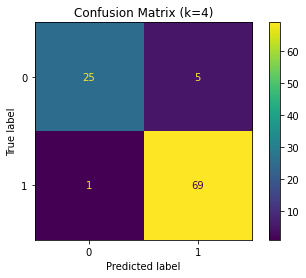

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(test2,Y_testout)

plt.title(f"Confusion Matrix (k=4)")
plt.show()

In [46]:
TN, FP, FN, TP = confusionmatrix.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
precision = TP / (TP + FP)

F1 = 2 * precision * TPR / (precision + TPR)

print("TPR =", TPR)
print("TNR =", TNR)
print("Precision =", precision)
print("F1 Score =", F1)

TPR = 0.9857142857142858
TNR = 0.8333333333333334
Precision = 0.9324324324324325
F1 Score = 0.9583333333333333


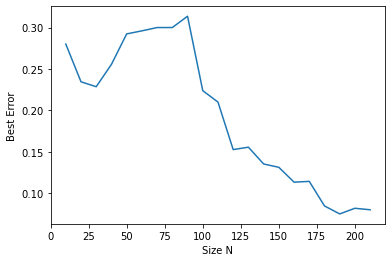

In [47]:
best_error = []


for N in range(10, 211, 10):

    n0 = N // 3
    n1 = N - n0

    traindata = pd.concat([class0.iloc[:n0],class1.iloc[:n1]])
    testdata = pd.concat([class0.iloc[n0:],class1.iloc[n1:]])

    X_train = traindata.drop("Class", axis=1)
    Y_train = traindata["Class"]
    X_test = testdata.drop("Class", axis=1)
    Y_test = testdata["Class"]
    
    test_errors = []

    for k in range(1, N, 5):

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, Y_train)
        Y_testout = knn.predict(X_test)
        test_error = 1 - accuracy_score(Y_test, Y_testout)
        test_errors.append(test_error)
        
    best_error.append(min(test_errors))

    
plt.plot(range(10, 211, 10), best_error)
plt.xlabel("Size N")
plt.ylabel("Best Error")
plt.show()

In [97]:
# d

In [98]:
class0 = df[df["Class"] == 0]
class1 = df[df["Class"] == 1]

traindata = pd.concat([class0.iloc[:70],class1.iloc[:140]])

testdata = pd.concat([class0.iloc[70:],class1.iloc[140:]])

In [99]:
test_errors = []

for k in range(1, 197, 5):

    knn = KNeighborsClassifier(n_neighbors=k,metric="minkowski", p = 1)

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    test_errors.append(test_error)
    

k_values = list(range(1, 197, 5))

best_error = min(test_errors)
index = test_errors.index(best_error)
k_star = k_values[index]


k_minkowskip1 = k_star
best_error_minkowskip1 = best_error

print(k_star)
print(best_error)

6
0.10999999999999999


In [100]:
best_logp = None
best_error = 1

for exponent in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]:

    p = 10 ** exponent
    knn = KNeighborsClassifier(n_neighbors=k_star, metric="minkowski",p=p)

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    error = 1 - accuracy_score(Y_test, Y_testout)

    if (error < best_error):
        best_error = error
        best_p = p
        best_logp = exponent

p_minkowskilog = best_logp
best_error_minkowskilog = best_error
        
        
print(best_logp)
print(best_error)

0.6
0.06000000000000005


In [101]:
import math

print(math.log10(best_p))

test_errors = []

for k in range(1, 197, 5):

    knn = KNeighborsClassifier(n_neighbors=k,metric="chebyshev")

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    test_errors.append(test_error)
k_values = list(range(1, 197, 5))

best_error = min(test_errors)
index = test_errors.index(best_error)
k_star = k_values[index]


k_chebyshev = k_star
best_error_chebyshev = best_error

print(k_star)
print(best_error)

0.6
16
0.07999999999999996


In [102]:
import numpy as np

V = np.cov(X_train.T)
VI = np.linalg.inv(V)

test_errors = []

for k in range(1, 197, 5):

    knn = KNeighborsClassifier(n_neighbors=k, metric="mahalanobis", metric_params={"VI": VI})

    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_error = 1 - accuracy_score(Y_test, Y_testout)
    test_errors.append(test_error)

k_values = list(range(1, 197, 5))

best_error = min(test_errors)
index = test_errors.index(best_error)
k_star = k_values[index]

k_mahalanobis = k_star
best_error_mahalanobis = best_error

print(k_star)
print(best_error)

1
0.17000000000000004


In [103]:
alloutput = [
            ["Manhattan",   k_minkowskip1,   "-",                  best_error_minkowskip1],
            ["Minkowski",   k_minkowskip1,   p_minkowskilog,  best_error_minkowskilog],
            ["Chebyshev",   k_chebyshev,   "-",                  best_error_chebyshev],
            ["Mahalanobis", k_mahalanobis, "-",                  best_error_mahalanobis]]

result = pd.DataFrame(alloutput,columns=["Distance", "Best-k", "Best log10p", "Test Error"])

print(result)

      Distance  Best-k Best log10p  Test Error
0    Manhattan       6           -        0.11
1    Minkowski       6         0.6        0.06
2    Chebyshev      16           -        0.08
3  Mahalanobis       1           -        0.17


In [104]:
# e

In [105]:
test_errors = []

for k in range(1, 197, 5):
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", weights="distance")
    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_errors.append(1 - accuracy_score(Y_test, Y_testout))

best_error_euclidean = min(test_errors)
k_euclidean = list(range(1, 197, 5))[test_errors.index(best_error_euclidean)]

In [106]:
test_errors = []

for k in range(1, 197, 5):
    knn = KNeighborsClassifier(n_neighbors=k,metric="manhattan",weights="distance")
    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_errors.append(1 - accuracy_score(Y_test, Y_testout))

best_error_manhattan = min(test_errors)
k_manhattan = list(range(1, 197, 5))[test_errors.index(best_error_manhattan)]

In [107]:
test_errors = []

for k in range(1, 197, 5):
    knn = KNeighborsClassifier(n_neighbors=k,metric="chebyshev",weights="distance")
    knn.fit(X_train, Y_train)
    Y_testout = knn.predict(X_test)
    test_errors.append(1 - accuracy_score(Y_test, Y_testout))

best_error_chebyshev = min(test_errors)
k_chebyshev = list(range(1, 197, 5))[test_errors.index(best_error_chebyshev)]

In [108]:
outputs = [
          ["Euclidean",  k_euclidean,  best_error_euclidean],
          ["Manhattan",  k_manhattan,  best_error_manhattan],
          ["Chebyshev",  k_chebyshev,  best_error_chebyshev],]

result = pd.DataFrame(outputs, columns=["Distance", "Best-k", "Test Error"])
print(result)

    Distance  Best-k  Test Error
0  Euclidean       6        0.10
1  Manhattan      26        0.10
2  Chebyshev      16        0.11


In [109]:
# f

In [110]:
print("The min training error is 0. Because, when KNN(k=1) and Euclidean distance, every training point is its own nearest neighbor. So that all training points are classified correctly.")

The min training error is 0. Because, when KNN(k=1) and Euclidean distance, every training point is its own nearest neighbor. So that all training points are classified correctly.
